In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import shap

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor

ROOT = Path.cwd().parents[1]
print(ROOT)

DATA_RAW = ROOT/"data/raw"
DATA_PROCESSED = ROOT/"data/processed"

c:\Users\sebas\PycharmProjects\Git\BoxOffice_Oracle


In [2]:
model_df = pd.read_csv(
    DATA_RAW/"fe_groups/g4.csv"
)

print(model_df.shape)
model_df.head()

(2255, 46)


,Unnamed: 0,tconst,primaryTitle,startYear,opening_weekend_gross,opening_theaters,domestic_release_date,release_type,all_domestic_release_types,distributor,...,director_name,writer_name,actor_1_name,actor_2_name,actor_3_name,franchise,final_market_synopsis,g4_local_60d_mode_genre,g4_local_60d_mode_genre_count,g4_matches_local_60d_mode_genre
0,0,tt1311067,Halloween II,2009.0,7676836.0,1217.0,1981-10-30,Wide,Wide,Universal,...,Rob Zombie,Rob Zombie,Scout Taylor-Compton,Tyler Mane,Malcolm McDowell,Halloween,Laurie Strode struggles to come to terms with ...,NaN,0,0
1,1,tt0816462,Conan the Barbarian,2011.0,9479373.0,1358.0,1982-05-14,Wide,Wide,Universal,...,Marcus Nispel,Thomas Dean Donnelly,Jason Momoa,Ron Perlman,Rose McGowan,Conan,A horde of rampaging warriors massacre the par...,NaN,0,0
2,2,tt4731008,The Wild Life,2016.0,4001400.0,1140.0,1984-09-28,Wide,Wide,NaN,...,Vincent Kesteloot,Daniel Defoe,Matthias Schweighöfer,Kaya Yanar,Ilka Bessin,NaN,"Flight is the ultimate superpower, an extraord...",NaN,0,0
3,3,tt1160419,Dune: Part One,2021.0,6025091.0,915.0,1984-12-14,Wide,Wide,Universal,...,Denis Villeneuve,Jon Spaihts,Timothée Chalamet,Rebecca Ferguson,Zendaya,Dune,"Paul Atreides, a brilliant and gifted young ma...",NaN,0,0
4,4,tt1540128,Playing for Keeps,2012.0,1406300.0,1148.0,1986-10-03,Wide,Wide,Universal,...,Gabriele Muccino,Robbie Fox,Gerard Butler,Jessica Biel,Dennis Quaid,NaN,"A romantic comedy about a charming, down-on-hi...",NaN,0,0


In [3]:
target = "log_opening_weekend_gross"

num_group_features = [
    'g4_local_60d_mode_genre_count',
]

numeric_features = [
    # "opening_theaters",
    "production_budget",
    "runtime_minutes",
    "release_month",
    "release_day_of_year",
] + num_group_features

people_features = [
    "director_id",
    "writer_id",
    "actor_1",
    "actor_2",
    "actor_3",
]

cat_group_feature = [
    'g4_local_60d_mode_genre',
    'g4_matches_local_60d_mode_genre'
]

categorical_features = [
    # "release_type",
    "distributor",
    "MPA_rating",
    "genre",
    "subgenre",
    "source",
    "production_method",
    "creative_type",
    "production_countries",
    "languages",
    "franchise"
 ] + people_features + cat_group_feature

In [4]:
model_df = model_df[
    model_df["franchise"].isna() |
    (model_df["franchise"].astype(str).str.strip() == "")
].copy()

In [5]:
feature_cols = numeric_features + categorical_features

model_data = model_df[
    feature_cols + [target, "opening_weekend_gross"]
].copy()

X = model_data[feature_cols]
y = model_data[target]

print(X.shape)
print(y.shape)

(1493, 22)
(1493,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
y_test_dollars = np.expm1(y_test)

In [8]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [9]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)

    r2_log = r2_score(y_test, pred_log)
    mae_log = mean_absolute_error(y_test, pred_log)

    pred_dollars = np.expm1(pred_log)

    mae_dollars = mean_absolute_error(y_test_dollars, pred_dollars)

    results = {
        "model": name,
        "r2_log": r2_log,
        "mae_log": mae_log,
        "mae_dollars": mae_dollars
    }

    return results, pred_log, pred_dollars

In [10]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_results, ridge_pred_log, ridge_pred_dollars = evaluate_model(
    "Ridge Baseline",
    ridge_model,
    X_train,
    X_test,
    y_train,
    y_test
)

ridge_results

c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


{'model': 'Ridge Baseline',
 'r2_log': 0.4324001052249622,
 'mae_log': 0.890363563889518,
 'mae_dollars': 7463042.004970953}

In [11]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_results, xgb_pred_log, xgb_pred_dollars = evaluate_model(
    "XGBoost Baseline",
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

xgb_results

c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


{'model': 'XGBoost Baseline',
 'r2_log': 0.507422516128395,
 'mae_log': 0.8001851681410143,
 'mae_dollars': 6241535.4139449205}

In [12]:
results_df = pd.DataFrame([
    ridge_results,
    xgb_results
])

results_df

,model,r2_log,mae_log,mae_dollars
0,Ridge Baseline,0.432400,0.890364,7.463042e+06
1,XGBoost Baseline,0.507423,0.800185,6.241535e+06


In [13]:
plot_df = pd.DataFrame({
    "actual": y_test_dollars,
    "predicted": xgb_pred_dollars
})

fig = px.scatter(
    plot_df,
    x="actual",
    y="predicted",
    title="XGBoost Baseline: Actual vs Predicted",
    opacity=0.6
)

fig.add_shape(
    type="line",
    x0=plot_df["actual"].min(),
    y0=plot_df["actual"].min(),
    x1=plot_df["actual"].max(),
    y1=plot_df["actual"].max(),
)

fig.show()

In [14]:
X_train_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_train)
)

X_test_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_test)
)

feature_names = (
    xgb_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

trained_xgb = xgb_model.named_steps["model"]

c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
c:\Users\sebas\miniconda3\envs\rr\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['franchise']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


In [15]:
explainer = shap.TreeExplainer(trained_xgb)

X_shap = X_test_transformed[:500]

shap_values = explainer.shap_values(X_shap)

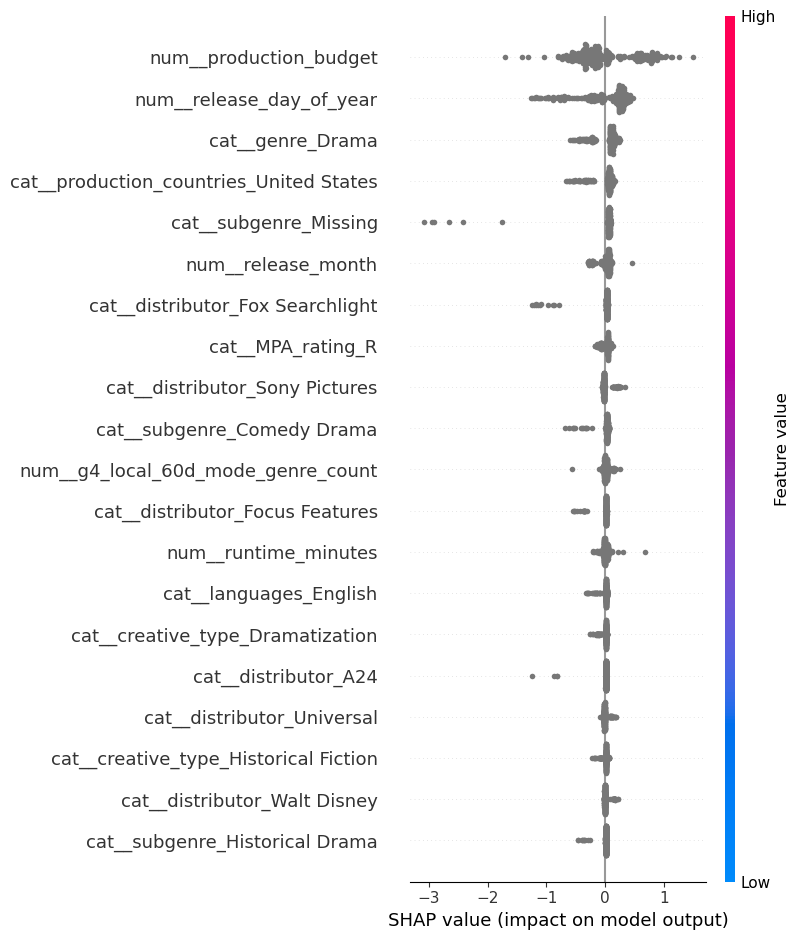

In [16]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
)

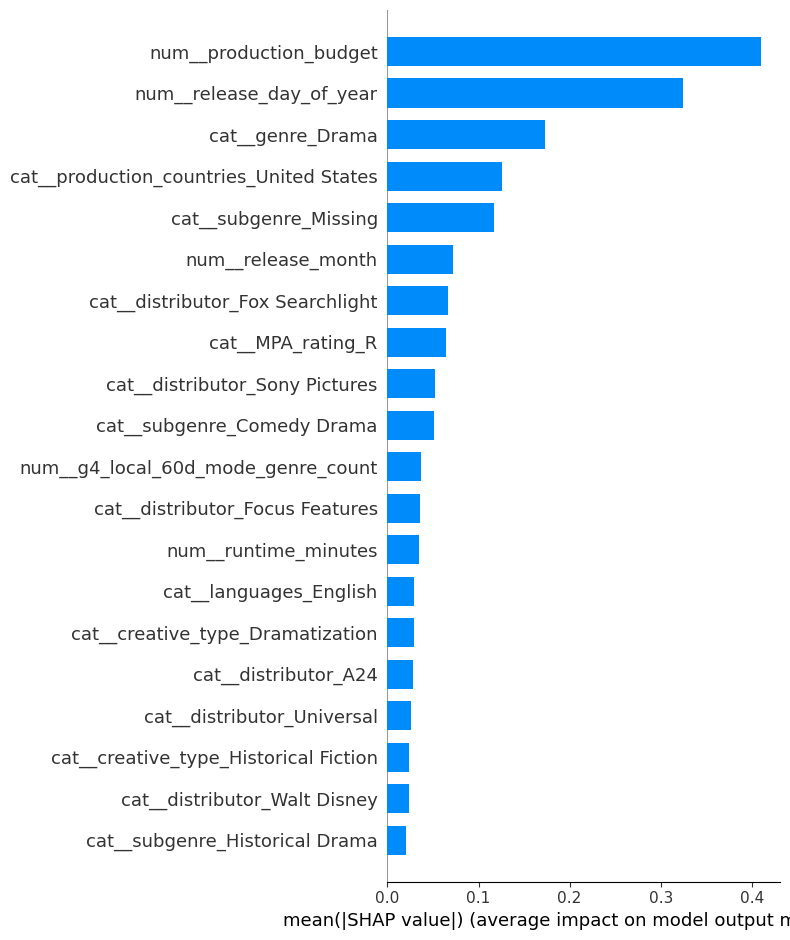

In [17]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar"
)

In [18]:
error_df = X_test.copy()

error_df["actual_log"] = y_test
error_df["pred_log"] = xgb_pred_log

error_df["actual_opening_weekend"] = np.expm1(y_test)
error_df["pred_opening_weekend"] = xgb_pred_dollars

error_df["abs_error"] = (
    error_df["actual_opening_weekend"] -
    error_df["pred_opening_weekend"]
).abs()

error_df.sort_values("abs_error", ascending=False).head(20)

,production_budget,runtime_minutes,release_month,release_day_of_year,g4_local_60d_mode_genre_count,distributor,MPA_rating,genre,subgenre,source,...,actor_1,actor_2,actor_3,g4_local_60d_mode_genre,g4_matches_local_60d_mode_genre,actual_log,pred_log,actual_opening_weekend,pred_opening_weekend,abs_error
39,25000000.0,127.0,2,56,12,Newmarket Films,R,Drama,Faith-Based Drama,Based on Religious Text,...,nm0001029,nm0000899,nm0411581,Comedy,0,18.244517,15.490124,83848082.0,5336729.5,78511352.5
1393,95000000.0,105.0,3,72,7,Walt Disney,PG,Drama,Historical Drama,Based on Folk Tale/Legend/Fairytale,...,nm4141252,nm0000949,nm0534635,Comedy,0,18.033213,16.803850,67877361.0,19852692.0,48024669.0
1798,75000000.0,86.0,11,313,11,Universal,PG,Adventure,Family Adventure,Based on Fiction Book/Short Story,...,nm1212722,nm7372981,nm0429069,Drama,0,18.028717,16.861286,67572855.0,21026332.0,46546523.0
1795,55000000.0,134.0,11,306,10,20th Century Fox,PG-13,Drama,Biographical Drama,Based on Real Life Events,...,nm1785339,nm2377903,nm3152605,Drama,1,17.748534,16.326326,51061119.0,12314972.0,38746147.0
741,175000000.0,89.0,5,149,6,Walt Disney,PG,Adventure,Family Adventure,Original Screenplay,...,nm0000799,nm2973712,nm0001652,Action,0,18.036617,17.322834,68108790.0,33358860.0,34749930.0
1396,130000000.0,94.0,3,86,7,20th Century Fox,PG,Adventure,Family Adventure,Based on Fiction Book/Short Story,...,nm8289285,NaN,NaN,Action,0,17.768824,17.097219,52107731.0,26621228.0,25486503.0
1377,56200000.0,124.0,12,359,10,Walt Disney,PG,Musical,Epic Musical,Based on Musical or Opera,...,nm0447695,nm0000658,nm1517976,Drama,0,17.251171,15.555565,31051923.0,5697652.0,25354271.0
803,105000000.0,97.0,11,329,12,Walt Disney,G,Adventure,"Family Adventure, Musical-Adventure",Based on Fiction Book/Short Story,...,nm0741242,nm0202966,nm0001856,Drama,0,13.574955,17.068945,786190.0,25879064.0,25092874.0
990,200000000.0,113.0,6,168,7,Warner Bros.,PG-13,Action,Action Adventure,Based on Comic/Graphic Novel,...,nm0005351,nm0515116,nm0765597,Comedy,0,17.789086,17.189838,53174303.0,29204648.0,23969655.0
1557,60000000.0,96.0,9,253,8,Warner Bros.,PG-13,Drama,Biographical Drama,Based on Factual Book/Article,...,nm0000158,nm0001173,nm0001473,Adventure,0,17.371667,16.266394,35028301.0,11598584.0,23429717.0


In [19]:
results_df.to_csv(
    DATA_PROCESSED/"feature_testing/results/g4_model_results.csv",
    index=False
)

error_df.to_csv(
    DATA_PROCESSED/"feature_testing/errors/g4_xgb_test_errors.csv",
    index=False
)